## Introduction
This notebook provides a comprehensive guide to auditing skeletons generated from motion capture data. It includes functionalities to load CSV files containing the skeleton data, extract the 3D positions of relevant bones, calculate specific measurements (such as shoulder width, arm lengths, leg lengths, and overall height), and visualize the bone positions in 3D space.

The notebook is designed to compare the generated skeletons with manual human (tape-based) measurements, allowing for an accurate assessment of the data's quality and consistency.

This notebook, inluding code was generated with ChatGPTs code interpreter. To see this process look here https://chat.openai.com/share/b2772194-61dc-45ff-bd64-c4eba589cb58.

### Measurements Calculated
- **Shoulder Width**: Distance between the left and right upper arms.
- **Upper Arm Length (Left & Right)**: Distance between the upper arm and lower arm.
- **Lower Arm Length (Left & Right)**: Distance between the lower arm and hand.
- **Upper Leg Length (Left & Right)**: Distance between the thigh and shin.
- **Lower Leg Length (Left & Right)**: Distance between the shin and foot.
- **Overall Height**: Average of the distances from the left and right feet to the head.

### Data Structure
The expected CSV file structure includes the following rows:
- 1st row: General information about the take and export settings.
- 3rd row: Data type (e.g., bone) for each corresponding column.
- 4th row: Marker or asset labels (bone names).
- 6th and 7th row: Header label for the data included in the column (position and orientation on X/Y/Z).
- Subsequent rows: Frame data with X/Y/Z positions and W/X/Y/Z rotation quaternion for each bone.

**Note**: The coordinate system and units used in the CSV files should be consistent with the visualization and measurement calculation within this notebook. Adjustments may be needed based on the specific coordinate system used in the motion capture setup.

Let's start by loading the CSV files and extracting the relevant data.


In [23]:
# Importing required libraries
import csv

# Function to extract bone names and position data from the CSV file
def extract_bone_data(file_path):
    bone_names = []
    frames_data = []
    with open(file_path, 'r') as file:
        # Skip the first 3 rows
        for _ in range(3):
            file.readline()
        # Read the 4th row to extract the bone names corresponding to the position columns (every 7th starting from 6th)
        bone_names_line = file.readline().strip().split(",")
        bone_names = [bone_names_line[i] for i in range(6, len(bone_names_line), 7)]
        # Skip rows 5, 6, and 7
        for _ in range(3):
            file.readline()
        # Iterate through the remaining rows to extract position data for each frame
        for line in file:
            frame_data = line.strip().split(",")
            # Extract X, Y, Z position data for each bone (every 7th starting from 6th)
            positions = [(float(frame_data[i]), float(frame_data[i + 1]), float(frame_data[i + 2])) for i in range(6, len(frame_data), 7)]
            frames_data.append(positions)
    return bone_names, frames_data

# Path to the CSV file containing the skeleton data
file_path = "0-10\M-SMC-06262023-01.csv"  # Update this path

# Extracting bone names and position data
bone_names, frames_data = extract_bone_data(file_path)

# Displaying the bone names and the corresponding XYZ positions for the first frame
bone_names_and_positions_first_frame = list(zip(bone_names, frames_data[0]))
bone_names_and_positions_first_frame


[('SMC-06262023-01:Hip', (-58.573296, 890.913696, -289.223877)),
 ('SMC-06262023-01:Ab', (-70.900574, 985.19574, -300.188568)),
 ('SMC-06262023-01:Chest', (-89.535187, 1204.60437, -376.464142)),
 ('SMC-06262023-01:Neck', (-106.369324, 1387.781616, -429.715607)),
 ('SMC-06262023-01:Head', (-104.214577, 1483.816895, -387.916595)),
 ('SMC-06262023-01:LShoulder', (-68.746849, 1382.253662, -423.479492)),
 ('SMC-06262023-01:LUArm', (-10.68696, 1354.534424, -383.657654)),
 ('SMC-06262023-01:LFArm', (28.616932, 1105.712524, -190.386749)),
 ('SMC-06262023-01:LHand', (-33.528263, 1009.610901, 20.518034)),
 ('SMC-06262023-01:RShoulder', (-140.339355, 1371.501587, -437.833008)),
 ('SMC-06262023-01:RUArm', (-204.07515, 1331.059692, -432.608398)),
 ('SMC-06262023-01:RFArm', (-334.153259, 1062.248657, -324.760986)),
 ('SMC-06262023-01:RHand', (-243.695206, 1096.128662, -105.106888)),
 ('SMC-06262023-01:LThigh', (31.01449, 904.676025, -271.607117)),
 ('SMC-06262023-01:LShin', (125.576485, 499.487885, 

In [24]:
# Function to calculate Euclidean distance between two points
def calculate_distance(bone1, bone2, positions):
    x1, y1, z1 = positions[bone_names.index(bone1)]
    x2, y2, z2 = positions[bone_names.index(bone2)]
    return ((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2) ** 0.5

# Measurements to be calculated (Update the bone names according to the specific naming convention in your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]
measurements = {
    "Shoulder Width": (f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:RUArm"),
    "Upper Arm Length (Left)": (f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:LFArm"),
    "Lower Arm Length (Left)": (f"{skeleton_identifier}:LFArm", f"{skeleton_identifier}:LHand"),
    "Upper Arm Length (Right)": (f"{skeleton_identifier}:RUArm", f"{skeleton_identifier}:RFArm"),
    "Lower Arm Length (Right)": (f"{skeleton_identifier}:RFArm", f"{skeleton_identifier}:RHand"),
    "Upper Leg Length (Left)": (f"{skeleton_identifier}:LThigh", f"{skeleton_identifier}:LShin"),
    "Lower Leg Length (Left)": (f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:LFoot"),
    "Upper Leg Length (Right)": (f"{skeleton_identifier}:RThigh", f"{skeleton_identifier}:RShin"),
    "Lower Leg Length (Right)": (f"{skeleton_identifier}:RShin", f"{skeleton_identifier}:RFoot"),
}

# Calculating the measurements for the first 10 frames
all_frame_measurements = []
for frame_positions in frames_data[:10]:
    frame_measurements = {name: calculate_distance(bone1, bone2, frame_positions) for name, (bone1, bone2) in measurements.items()}
    # Calculating overall height (average of Left and Right Feet to Head)
    frame_measurements["Overall Height"] = (calculate_distance(f"{skeleton_identifier}:Head", f"{skeleton_identifier}:LFoot", frame_positions) +
                                            calculate_distance(f"{skeleton_identifier}:Head", f"{skeleton_identifier}:RFoot", frame_positions)) / 2
    all_frame_measurements.append(frame_measurements)

all_frame_measurements



[{'Shoulder Width': 200.86371103835918,
  'Upper Arm Length (Left)': 317.507128369548,
  'Lower Arm Length (Left)': 239.9549430561897,
  'Upper Arm Length (Right)': 317.5070885096659,
  'Lower Arm Length (Right)': 239.95507258556637,
  'Upper Leg Length (Left)': 423.27220509591416,
  'Lower Leg Length (Left)': 408.8311867255595,
  'Upper Leg Length (Right)': 423.2719270094128,
  'Lower Leg Length (Right)': 408.8310346829681,
  'Overall Height': 1434.957259843359},
 {'Shoulder Width': 200.86371103835918,
  'Upper Arm Length (Left)': 317.507128369548,
  'Lower Arm Length (Left)': 239.95498475783052,
  'Upper Arm Length (Right)': 317.5069979210709,
  'Lower Arm Length (Right)': 239.95506704639175,
  'Upper Leg Length (Left)': 423.27210812045274,
  'Lower Leg Length (Left)': 408.83109821183075,
  'Upper Leg Length (Right)': 423.272049882845,
  'Lower Leg Length (Right)': 408.83109399946244,
  'Overall Height': 1434.9572588093688},
 {'Shoulder Width': 194.89982713251607,
  'Upper Arm Length

<IPython.core.display.Javascript object>


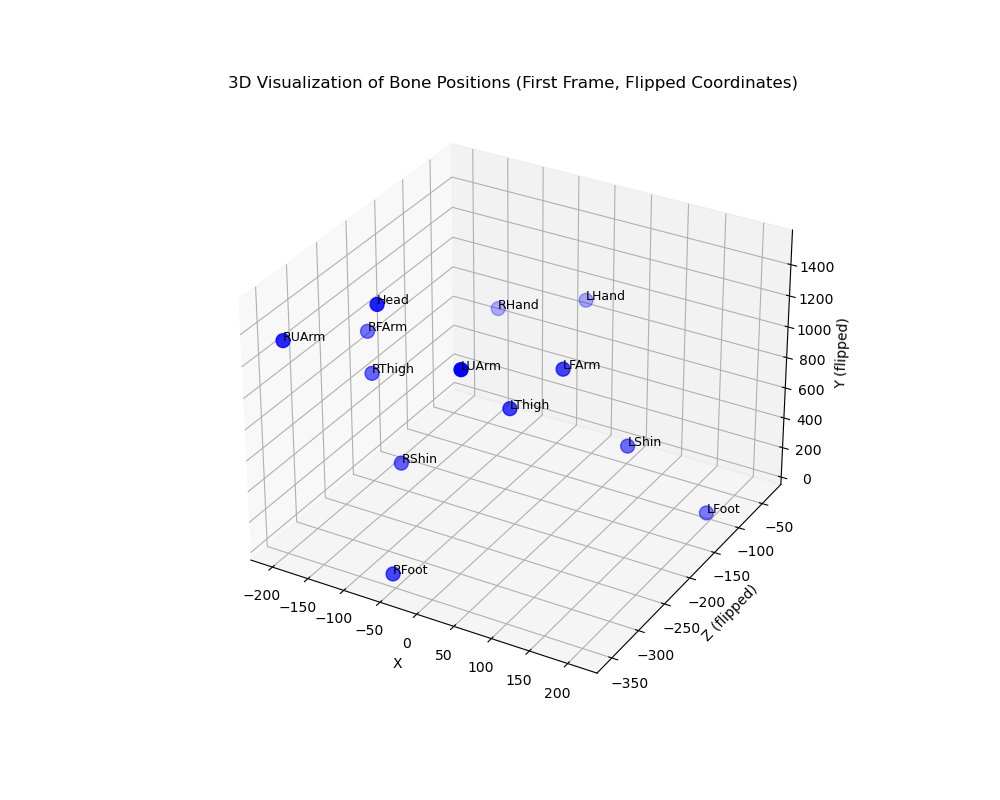

In [22]:
%matplotlib notebook
# Importing required libraries for visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Bones of interest (update these according to the specific naming convention in your CSV file)
bones_of_interest = [
    f"{skeleton_identifier}:Head",
    f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:RUArm",
    f"{skeleton_identifier}:LFArm", f"{skeleton_identifier}:RFArm",
    f"{skeleton_identifier}:LHand", f"{skeleton_identifier}:RHand",
    f"{skeleton_identifier}:LThigh", f"{skeleton_identifier}:RThigh",
    f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:RShin",
    f"{skeleton_identifier}:LFoot", f"{skeleton_identifier}:RFoot",
]

# Function to plot the bone positions for the given frame with flipped Y and Z coordinates
def plot_bone_positions_flipped(frame_positions):
    # Extracting the X, Y, Z coordinates for the selected bones (with flipped Y and Z)
    x_values = [frame_positions[bone_names.index(bone)][0] for bone in bones_of_interest]
    y_values = [frame_positions[bone_names.index(bone)][2] for bone in bones_of_interest]
    z_values = [frame_positions[bone_names.index(bone)][1] for bone in bones_of_interest]
    # Plotting the 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_values, y_values, z_values, c='blue', s=100)
    for i, bone_name in enumerate(bones_of_interest):
        ax.text(x_values[i], y_values[i], z_values[i], bone_name.split(":")[-1], fontsize=9)
    ax.set_xlabel('X')
    ax.set_ylabel('Z (flipped)')
    ax.set_zlabel('Y (flipped)')
    plt.title('3D Visualization of Bone Positions (First Frame, Flipped Coordinates)')
    plt.show()

# Plotting the bone positions for the first frame with flipped Y and Z coordinates
plot_bone_positions_flipped(frames_data[0])



## Conclusion
This notebook provides a comprehensive toolset for auditing and analyzing skeletons generated from motion capture data. The functionalities include loading CSV files containing the skeleton data, extracting 3D positions, calculating specific measurements, and visualizing the bone positions.

### Comparing with Manual Measurements
To compare the calculated measurements with manual human measurements, you can load the manual data and analyze the differences using statistical methods or visual comparisons. The consistency and accuracy of the motion capture data can be assessed by identifying any significant deviations or patterns in the discrepancies.

### Next Steps
- **Customization**: Depending on the specific motion capture setup and requirements, you may need to customize the bone names, measurements, and coordinate system adjustments within this notebook.
- **Further Analysis**: Additional analyses can be performed to assess the stability, reliability, and accuracy of the motion capture data across different participants, sessions, or conditions.
- **Integration with Other Data**: The extracted bone positions and measurements can be integrated with other data sources (such as biomechanical analyses, behavioral observations, or subjective assessments) to provide a comprehensive understanding of the captured movements.
- **Automated Processing**: This notebook can be adapted into a script or automated pipeline to process multiple CSV files and generate summary reports or visualizations for large-scale analyses.

Feel free to explore, modify, and expand the content of this notebook to suit your specific needs and objectives. If you have any questions or encounter any issues, please consult the official documentation of the motion capture system or seek expert assistance.

Happy auditing and analyzing!
